# Understand the dataset to start the project

In [1]:
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("all_data.csv")
print(df.head())

print(df.info()) # All the dataset is complete, no null values
# Country is stored as an object
# Year is stored as an int
# Life expectancy at both as a float 
# GDP is stored as a float

  Country  Year  Life expectancy at birth (years)           GDP
0   Chile  2000                              77.3  7.786093e+10
1   Chile  2001                              77.3  7.097992e+10
2   Chile  2002                              77.8  6.973681e+10
3   Chile  2003                              77.9  7.564346e+10
4   Chile  2004                              78.0  9.921039e+10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB
None


# Build some graphs to start looking at the data

### Has life expectancy increased over time in the six nations?

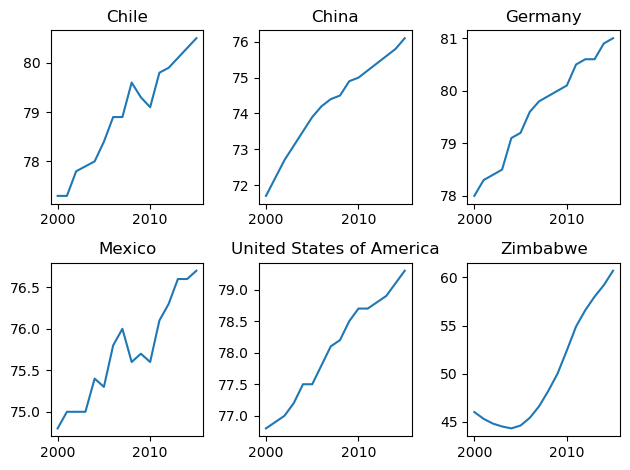

In [2]:
for i, country in enumerate(df["Country"].unique()):
    plt.subplot(2, 3, i + 1)
    country_df = df[df["Country"] == country]
    plt.plot(country_df["Year"], country_df["Life expectancy at birth (years)"])
    plt.title(country)
    plt.tight_layout()
plt.show()

We can see that in all the graphs there is an increase of Life expectance in the last couple years. Some of the country show a decline but after one or two years it increased again.

### Has GDP increased over time in the six nations?

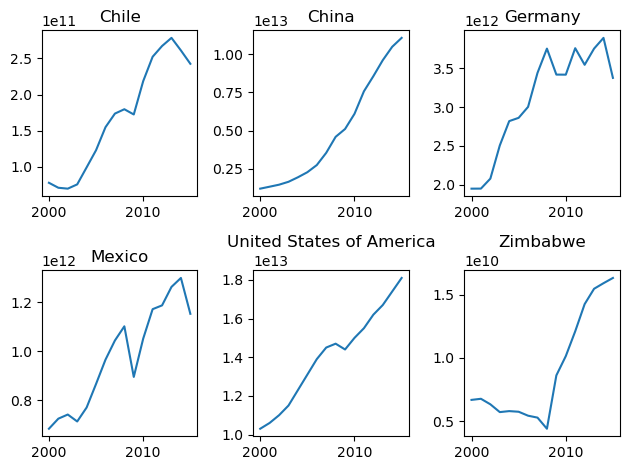

In [5]:
for i, country in enumerate(df["Country"].unique()):
    plt.subplot(2, 3, i + 1)
    country_df = df[df["Country"] == country]
    plt.plot(country_df["Year"], country_df["GDP"])
    plt.title(country)
    plt.tight_layout()
plt.show()

No, three out of the six countries show a decline in the year 2014, these countries are Chile, Germany and Mexico.

### Is there a correlation between GDP and life expectancy of a country?

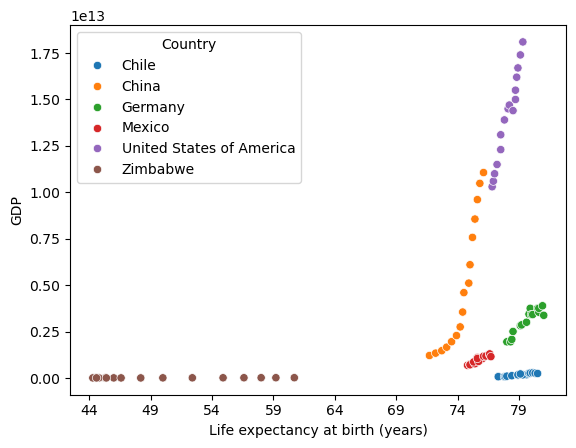

[[1.         0.94987667]
 [0.94987667 1.        ]]
[[1.         0.90852554]
 [0.90852554 1.        ]]
[[1.        0.9326989]
 [0.9326989 1.       ]]
[[1.         0.93223772]
 [0.93223772 1.        ]]
[[1.         0.98170924]
 [0.98170924 1.        ]]
[[1.        0.9661999]
 [0.9661999 1.       ]]


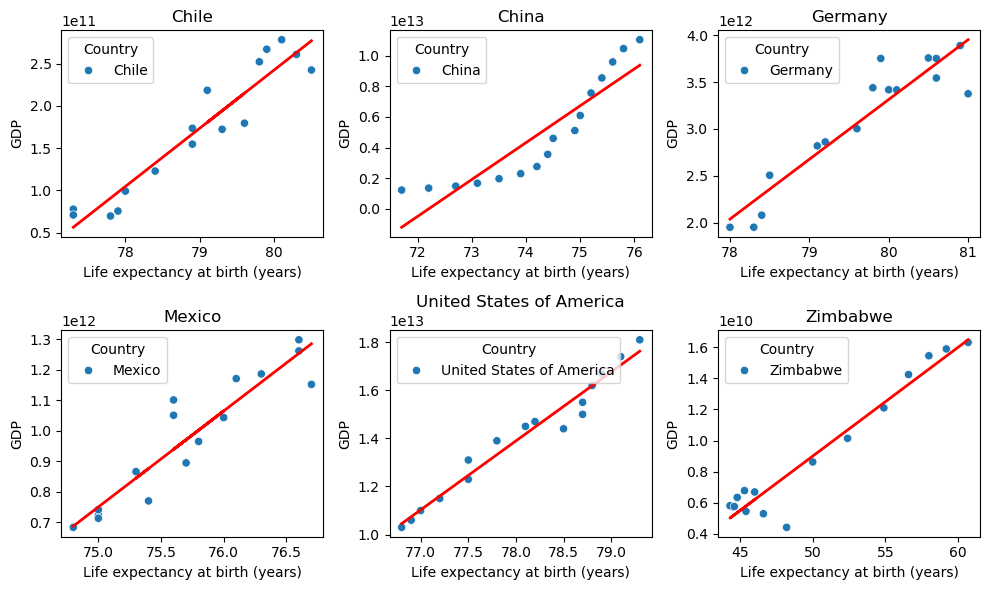

44.3
81.0


In [11]:
sns.scatterplot(data=df, x="Life expectancy at birth (years)", y="GDP", hue="Country")
ax = plt.subplot()
ax.set_xticks(np.arange(44, 81, 5))
plt.show()
plt.figure(figsize=(10, 6))
for i, country in enumerate(df["Country"].unique()):
    plt.subplot(2, 3, i + 1)
    country_df = df[df["Country"] == country]
    sns.scatterplot(data=country_df, x="Life expectancy at birth (years)", y="GDP", hue="Country")
    m, c = np.polyfit(country_df["Life expectancy at birth (years)"], country_df["GDP"], deg=1)
    plt.plot(country_df["Life expectancy at birth (years)"], m * country_df["Life expectancy at birth (years)"] + c, color="red", linewidth=2, label=f"Best Fit: y={m:.2f}x+{c:.2f}")
    plt.title(country)
    print(np.corrcoef(country_df["Life expectancy at birth (years)"], country_df["GDP"]))
    plt.tight_layout()
plt.show()


min_leab = min(df["Life expectancy at birth (years)"])
max_leab = max(df["Life expectancy at birth (years)"])
print(min_leab)
print(max_leab)

When looking at the whole dataset the countries are grouped and we can think they are completely correlated. However, if we look through each country, the correlation changes a lot from what the overall graph shows. The correlation graphs of each country varies widely. For example, China the points move like a wave, and we will have to investigate more to see if there is a recurrence in this year that makes the graph look like that. Another example is the USA, the points are close to the line of best fit, which means the points are correlated.

We can also take the Correlation Coefficient for each graph; all the graphs are between 0.2 and 0.6, under 1, meaning they are positively correlated.